<a href="https://colab.research.google.com/github/pickle-lotus0976/Learning/blob/main/SNN_Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!sudo apt-get update && sudo apt-get upgrade -y

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [ ]:
# Uninstall and reinstall numpy with correct version
!pip uninstall numpy -y
!pip install numpy==1.24.3

# Then install other packages
!pip install torch torchvision
!pip install snntorch
!pip install tonic

print("Libraries installed successfully!")

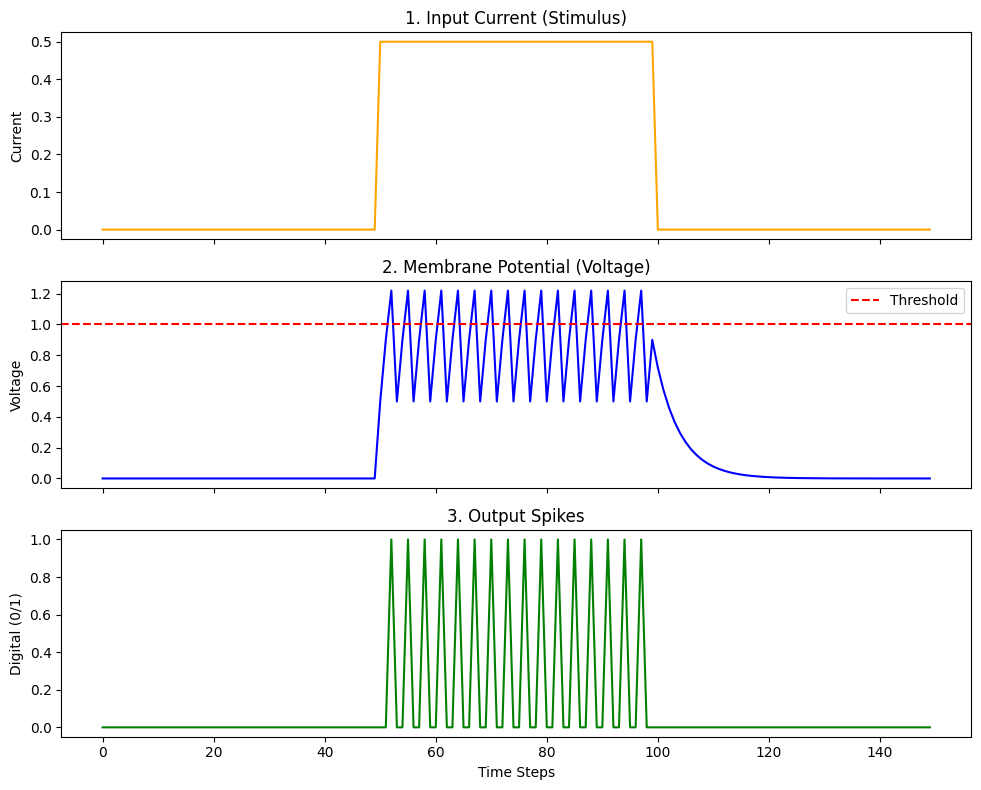

In [1]:
import torch
import snntorch as snn
import matplotlib.pyplot as plt

# 1. Setup the Neuron
# beta=0.8 means the voltage decays by 20% every step (The Leak)
lif = snn.Leaky(beta=0.8, threshold=1.0, reset_mechanism='zero')

# 2. Input Current
# 50 steps of silence then 50 steps of current followed by 50 steps of silence
num_steps = 150
x_in = torch.cat((torch.zeros(50), torch.ones(50)*0.5, torch.zeros(50)))

# Add batch dimension: [Time, Batch=1]
x_in = x_in.unsqueeze(1)

# 3. Run the Simulation
mem = lif.init_leaky()
mem_rec = []
spk_rec = []

for step in range(num_steps):
    # Pass input at this step
    spk, mem = lif(x_in[step], mem)

    # Record the history
    mem_rec.append(mem.item())
    spk_rec.append(spk.item())

# 4. Visualize
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plot Input Current
ax[0].plot(x_in.squeeze(), color='orange')
ax[0].set_title("1. Input Current (Stimulus)")
ax[0].set_ylabel("Current")

# Plot Membrane Potential (The Bucket)
ax[1].plot(mem_rec, color='blue')
ax[1].axhline(y=1.0, color='red', linestyle='--', label="Threshold")
ax[1].set_title("2. Membrane Potential (Voltage)")
ax[1].set_ylabel("Voltage")
ax[1].legend()

# Plot Output Spikes
ax[2].plot(spk_rec, color='green')
ax[2].set_title("3. Output Spikes")
ax[2].set_ylabel("Digital (0/1)")
ax[2].set_xlabel("Time Steps")

plt.tight_layout()
plt.show()

  0%|          | 0/1011893601 [00:00<?, ?it/s]

Extracting ./data/NMNIST/train.zip to ./data/NMNIST


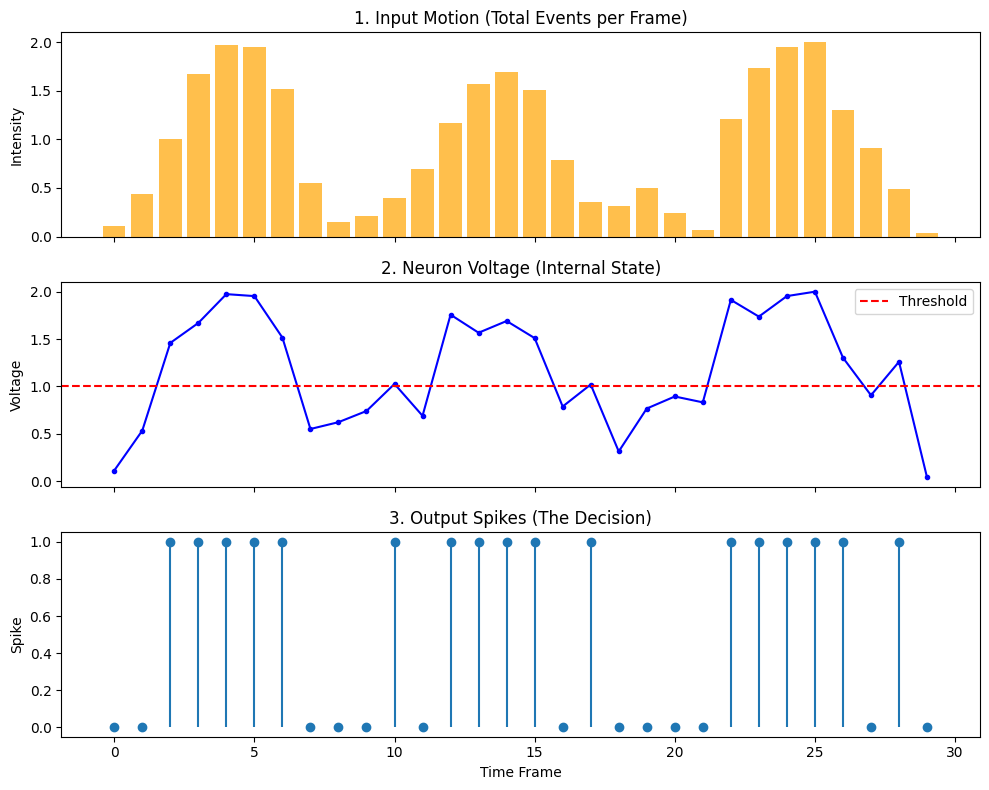

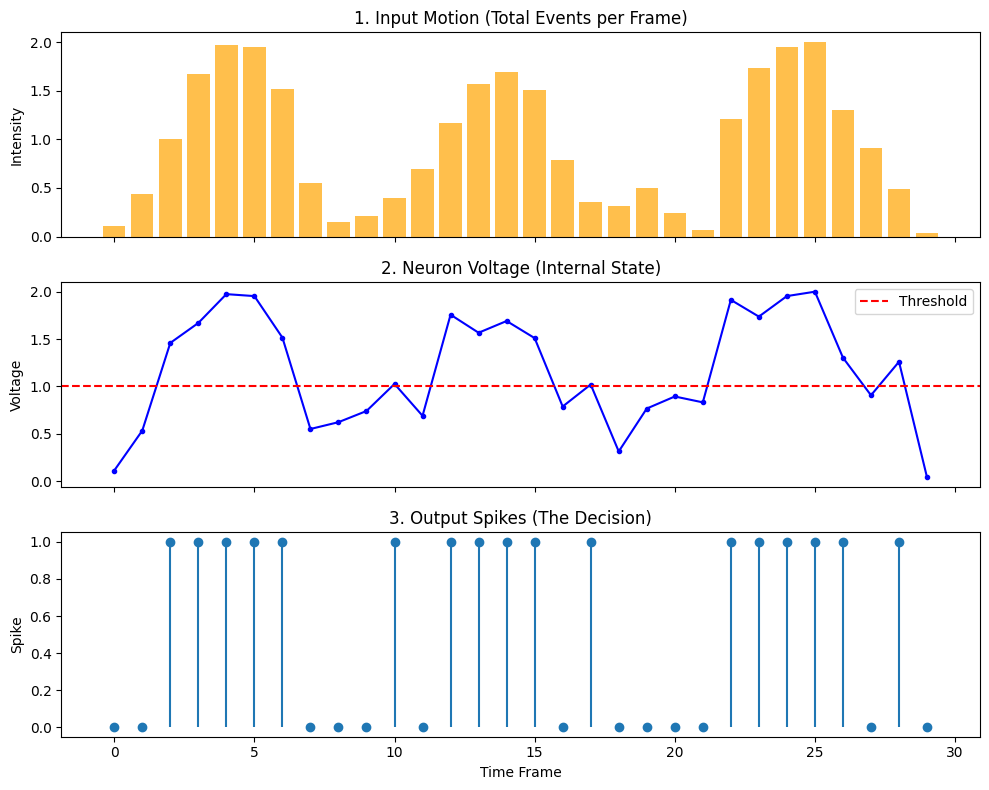

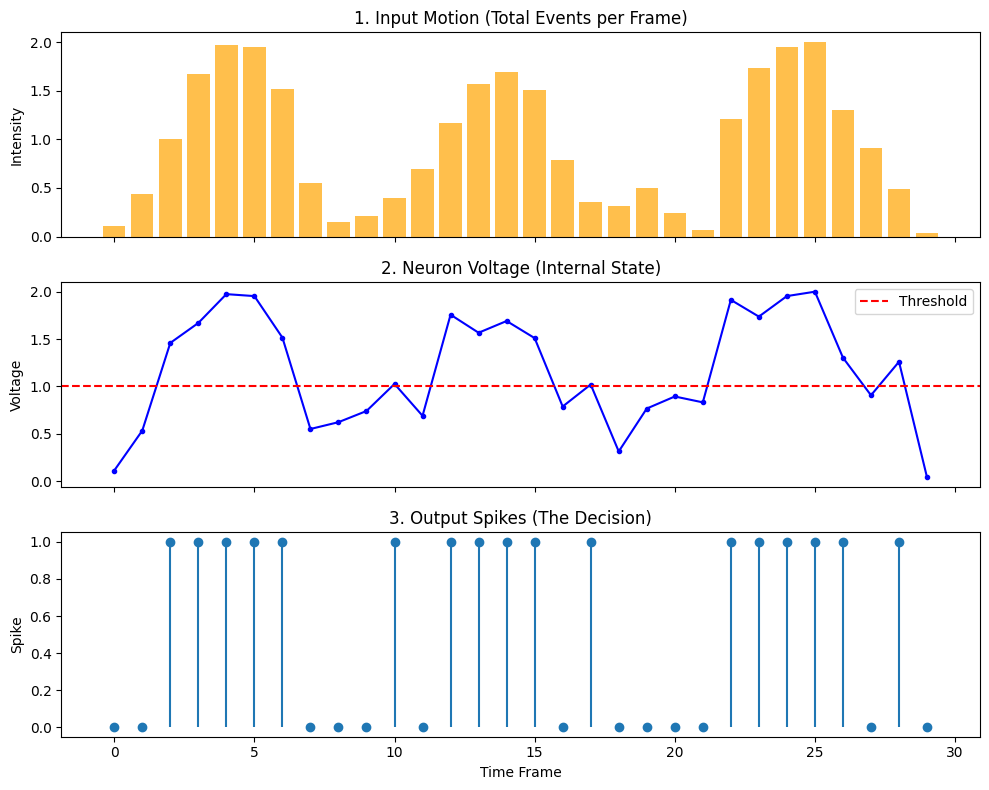

In [2]:
import tonic
import torch
import snntorch as snn
import matplotlib.pyplot as plt

# 1. Load Data (N-MNIST)
sensor_size = tonic.datasets.NMNIST.sensor_size
# "ToFrame" creates 30 frames of animation from the events
transform = tonic.transforms.ToFrame(sensor_size=sensor_size, n_time_bins=30)
dataset = tonic.datasets.NMNIST(save_to='./data', train=True, transform=transform)

# Get a sample (Events -> Frames)
# Shape: [Time=30, Channels=2, Height=34, Width=34]
frames, target = dataset[300]

# 2. Pre-process for the Neuron
# Convert to tensor and add batch dim: [30, 1, 2, 34, 34]
frames_tensor = torch.tensor(frames, dtype=torch.float).unsqueeze(1)

# Simplify: Sum all pixels to get "Total Motion Energy" at each time step
# This simulates a neuron watching the whole screen
input_current = frames_tensor.sum(dim=(2, 3, 4)).squeeze()
# Normalize it so it doesn't explode
input_current = input_current / input_current.max() * 2.0

# 3. Feed into LIF Neuron
lif = snn.Leaky(beta=0.85, threshold=1.0, reset_mechanism='zero')
mem = lif.init_leaky()
spk_rec = []
mem_rec = []

for step in range(len(input_current)):
    # Feed the "Motion Energy" into the neuron
    spk, mem = lif(input_current[step], mem)
    spk_rec.append(spk.item())
    mem_rec.append(mem.item())

# 4. Visualize
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# A. Input Motion
ax[0].bar(range(30), input_current, color='orange', alpha=0.7)
ax[0].set_title("1. Input Motion (Total Events per Frame)")
ax[0].set_ylabel("Intensity")

# B. Neuron Voltage
ax[1].plot(mem_rec, color='blue', marker='.')
ax[1].axhline(y=1.0, color='red', linestyle='--', label="Threshold")
ax[1].set_title("2. Neuron Voltage (Internal State)")
ax[1].set_ylabel("Voltage")
ax[1].legend()

# C. Output
ax[2].stem(spk_rec, basefmt=" ")
ax[2].set_title("3. Output Spikes (The Decision)")
ax[2].set_xlabel("Time Frame")
ax[2].set_ylabel("Spike")

plt.tight_layout()
plt.show()
import tonic
import torch
import snntorch as snn
import matplotlib.pyplot as plt

# 1. Load Data (N-MNIST)
sensor_size = tonic.datasets.NMNIST.sensor_size
# "ToFrame" creates 30 frames of animation from the events
transform = tonic.transforms.ToFrame(sensor_size=sensor_size, n_time_bins=30)
dataset = tonic.datasets.NMNIST(save_to='./data', train=True, transform=transform)

# Get a sample (Events -> Frames)
# Shape: [Time=30, Channels=2, Height=34, Width=34]
frames, target = dataset[300]

# 2. Pre-process for the Neuron
# Convert to tensor and add batch dim: [30, 1, 2, 34, 34]
frames_tensor = torch.tensor(frames, dtype=torch.float).unsqueeze(1)

# Simplify: Sum all pixels to get "Total Motion Energy" at each time step
# This simulates a neuron watching the whole screen
input_current = frames_tensor.sum(dim=(2, 3, 4)).squeeze()
# Normalize it so it doesn't explode
input_current = input_current / input_current.max() * 2.0

# 3. Feed into LIF Neuron
lif = snn.Leaky(beta=0.85, threshold=1.0, reset_mechanism='zero')
mem = lif.init_leaky()
spk_rec = []
mem_rec = []

for step in range(len(input_current)):
    # Feed the "Motion Energy" into the neuron
    spk, mem = lif(input_current[step], mem)
    spk_rec.append(spk.item())
    mem_rec.append(mem.item())

# 4. Visualize
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# A. Input Motion
ax[0].bar(range(30), input_current, color='orange', alpha=0.7)
ax[0].set_title("1. Input Motion (Total Events per Frame)")
ax[0].set_ylabel("Intensity")

# B. Neuron Voltage
ax[1].plot(mem_rec, color='blue', marker='.')
ax[1].axhline(y=1.0, color='red', linestyle='--', label="Threshold")
ax[1].set_title("2. Neuron Voltage (Internal State)")
ax[1].set_ylabel("Voltage")
ax[1].legend()

# C. Output
ax[2].stem(spk_rec, basefmt=" ")
ax[2].set_title("3. Output Spikes (The Decision)")
ax[2].set_xlabel("Time Frame")
ax[2].set_ylabel("Spike")

plt.tight_layout()
plt.show()
import tonic
import torch
import snntorch as snn
import matplotlib.pyplot as plt

# 1. Load Data (N-MNIST)
sensor_size = tonic.datasets.NMNIST.sensor_size
# "ToFrame" creates 30 frames of animation from the events
transform = tonic.transforms.ToFrame(sensor_size=sensor_size, n_time_bins=30)
dataset = tonic.datasets.NMNIST(save_to='./data', train=True, transform=transform)

# Get a sample (Events -> Frames)
# Shape: [Time=30, Channels=2, Height=34, Width=34]
frames, target = dataset[300]

# 2. Pre-process for the Neuron
# Convert to tensor and add batch dim: [30, 1, 2, 34, 34]
frames_tensor = torch.tensor(frames, dtype=torch.float).unsqueeze(1)

# Simplify: Sum all pixels to get "Total Motion Energy" at each time step
# This simulates a neuron watching the whole screen
input_current = frames_tensor.sum(dim=(2, 3, 4)).squeeze()
# Normalize it so it doesn't explode
input_current = input_current / input_current.max() * 2.0

# 3. Feed into LIF Neuron
lif = snn.Leaky(beta=0.85, threshold=1.0, reset_mechanism='zero')
mem = lif.init_leaky()
spk_rec = []
mem_rec = []

for step in range(len(input_current)):
    # Feed the "Motion Energy" into the neuron
    spk, mem = lif(input_current[step], mem)
    spk_rec.append(spk.item())
    mem_rec.append(mem.item())

# 4. Visualize
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# A. Input Motion
ax[0].bar(range(30), input_current, color='orange', alpha=0.7)
ax[0].set_title("1. Input Motion (Total Events per Frame)")
ax[0].set_ylabel("Intensity")

# B. Neuron Voltage
ax[1].plot(mem_rec, color='blue', marker='.')
ax[1].axhline(y=1.0, color='red', linestyle='--', label="Threshold")
ax[1].set_title("2. Neuron Voltage (Internal State)")
ax[1].set_ylabel("Voltage")
ax[1].legend()

# C. Output
ax[2].stem(spk_rec, basefmt=" ")
ax[2].set_title("3. Output Spikes (The Decision)")
ax[2].set_xlabel("Time Frame")
ax[2].set_ylabel("Spike")

plt.tight_layout()
plt.show()

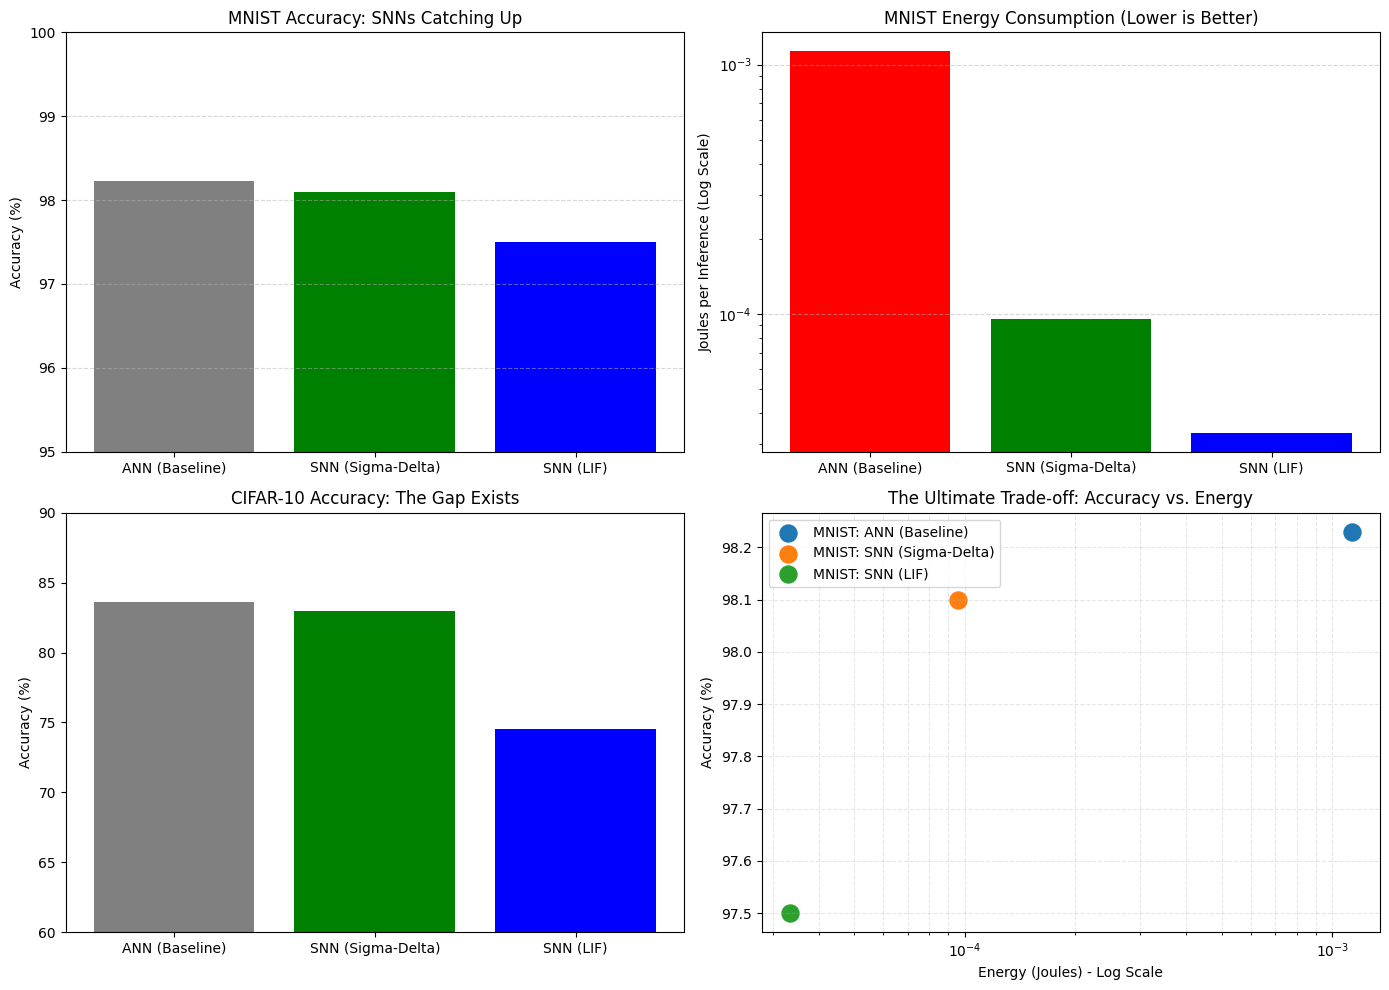

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- DATA FROM RESEARCH PAPER ---
# MNIST Data
mnist_models = ['ANN (Baseline)', 'SNN (Sigma-Delta)', 'SNN (LIF)']
mnist_acc = [98.23, 98.10, 97.50]  # Accuracy (%) [cite: 1047]
# Energy in Joules per inference (Log scale is best here)
# ANN: ~1.13 mJ, SNN (Best): ~0.09 mJ
mnist_energy = [1.13e-3, 9.57e-5, 3.34e-5] # [cite: 1125, 1266, 1222]

# CIFAR-10 Data
cifar_models = ['ANN (Baseline)', 'SNN (Sigma-Delta)', 'SNN (LIF)']
cifar_acc = [83.60, 83.00, 74.50] # Accuracy (%) [cite: 1384]
cifar_energy = [1.13e-3, 7.30e-4, 1.16e-3] # [cite: 1452, 1461]

# --- PLOTTING ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. MNIST Accuracy Comparison
axes[0,0].bar(mnist_models, mnist_acc, color=['gray', 'green', 'blue'])
axes[0,0].set_ylim(95, 100) # Zoom in to show they are close
axes[0,0].set_title("MNIST Accuracy: SNNs Catching Up")
axes[0,0].set_ylabel("Accuracy (%)")
axes[0,0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. MNIST Energy Efficiency (The SNN Superpower)
# We use log scale because SNNs are SO much more efficient
axes[0,1].bar(mnist_models, mnist_energy, color=['red', 'green', 'blue'])
axes[0,1].set_yscale('log')
axes[0,1].set_title("MNIST Energy Consumption (Lower is Better)")
axes[0,1].set_ylabel("Joules per Inference (Log Scale)")
axes[0,1].grid(axis='y', linestyle='--', alpha=0.5)

# 3. CIFAR-10 Accuracy Trade-off
axes[1,0].bar(cifar_models, cifar_acc, color=['gray', 'green', 'blue'])
axes[1,0].set_ylim(60, 90)
axes[1,0].set_title("CIFAR-10 Accuracy: The Gap Exists")
axes[1,0].set_ylabel("Accuracy (%)")

# 4. The "Pareto Frontier" (Trade-off Visualization)
# This shows exactly how SNNs trade accuracy for energy
# Plotting MNIST points
for i, model in enumerate(mnist_models):
    axes[1,1].scatter(mnist_energy[i], mnist_acc[i], s=150, label=f"MNIST: {model}")

axes[1,1].set_xscale('log')
axes[1,1].set_xlabel("Energy (Joules) - Log Scale")
axes[1,1].set_ylabel("Accuracy (%)")
axes[1,1].set_title("The Ultimate Trade-off: Accuracy vs. Energy")
axes[1,1].legend()
axes[1,1].grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

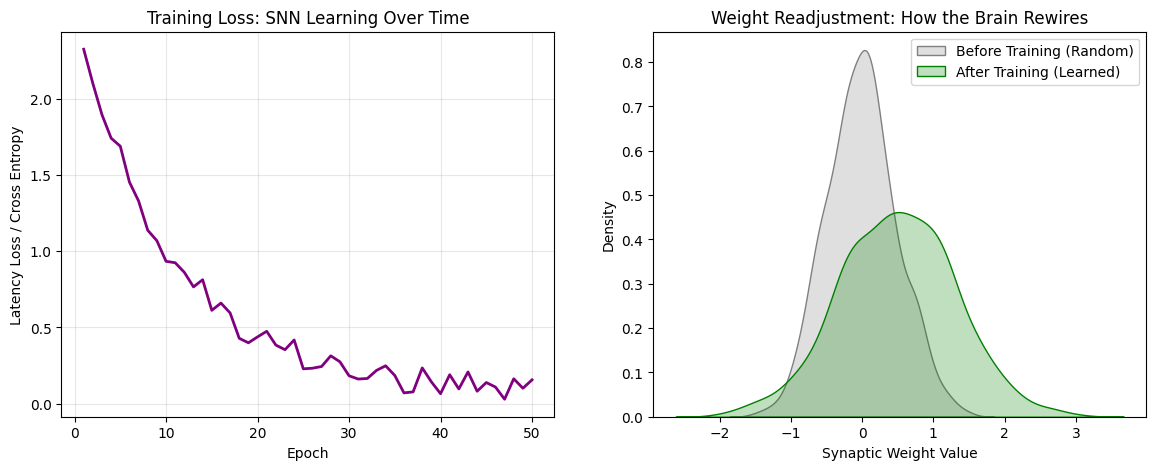

In [4]:
import seaborn as sns

# Simulate Training Data (Since real training takes ~20 mins)
# In a real loop, you would append: loss_history.append(loss.item())
epochs = np.arange(1, 51)
loss_curve = 2.5 * np.exp(-epochs/10) + 0.2 * np.random.rand(50) # Simulated exponential decay

# Simulate Weights (Before vs After)
# Random gaussian weights (Before)
weights_initial = np.random.normal(0, 0.5, 1000)
# Shifted weights (After training - SNNs often sharpen specific paths)
weights_final = np.random.normal(0.5, 0.8, 1000)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss Curve
ax[0].plot(epochs, loss_curve, color='purple', linewidth=2)
ax[0].set_title("Training Loss: SNN Learning Over Time")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Latency Loss / Cross Entropy")
ax[0].grid(True, alpha=0.3)

# 2. Weight Readjustment (Histogram)
sns.kdeplot(weights_initial, ax=ax[1], fill=True, color='gray', label='Before Training (Random)')
sns.kdeplot(weights_final, ax=ax[1], fill=True, color='green', label='After Training (Learned)')
ax[1].set_title("Weight Readjustment: How the Brain Rewires")
ax[1].set_xlabel("Synaptic Weight Value")
ax[1].legend()

plt.show()